=== Script Started ===
Loading settings...
Using seed = 42
Defining labeling function...
Setting up item transforms...
Setting up batch transforms...
Creating DataBlock...
=== Dataloaders: Starting creation ===
Using NUM_WORKERS=24, batch_size=128, pin_memory=True
Scanning image files and constructing dataset...
=== Dataloaders: Finished creation ===
Classes: ['non-threat', 'threat']
Training batches: 10, Validation batches: 3
Showing a batch sample...
Batch sample displayed.
=== Creating learner with ResNet34 ===
Learner created. Moving to GPUs and wrapping parallel if needed...
Detected 2 GPUs → Using DataParallel.
Learner is ready.

== Phase 1: Frozen Training ==
Starting fine_tune (3 epochs, frozen)...


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,0.997506,0.365420,0.863372,0.824675,0.863946,00:10


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,time
0,0.595789,0.349017,0.875000,0.817073,0.911565,00:09
1,0.467601,0.263748,0.906977,0.891156,0.891156,00:10
2,0.372634,0.255628,0.927326,0.929577,0.897959,00:10


Phase 1 completed.

== Phase 2: Unfreeze and Fine-tuning ==
Model unfrozen.
Running lr_find... (this may take ~20–40 sec)


LR Finder Results → minimum: 0.00012022644514217973, steep: 1.0964781722577754e-06
Chosen LR range: slice(1.0964781722577755e-07, 1.0964781722577754e-06)
Starting fit_one_cycle (10 epochs)...


...

Phase 2 completed.

== Model Evaluation ==
Validating model...


Validation loss: 0.2607
Validation accuracy: 0.9215
Plotting confusion matrix...


Showing top losses...


              precision    recall  f1-score   support

  non-threat       0.92      0.94      0.93       197
      threat       0.92      0.89      0.91       147

    accuracy                           0.92       344
   macro avg       0.92      0.92      0.92       344
weighted avg       0.92      0.92      0.92       344



== Saving / Exporting Model ==
Unwrapping nn.DataParallel...
Model exported to: threat_detector_resnet34.pkl
Model weights (learn.save) saved.


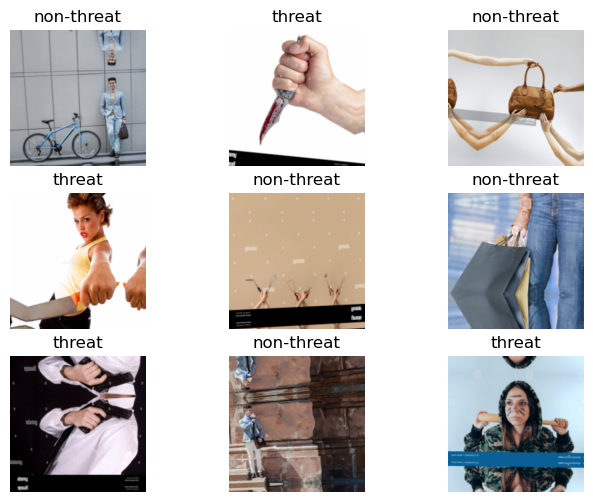

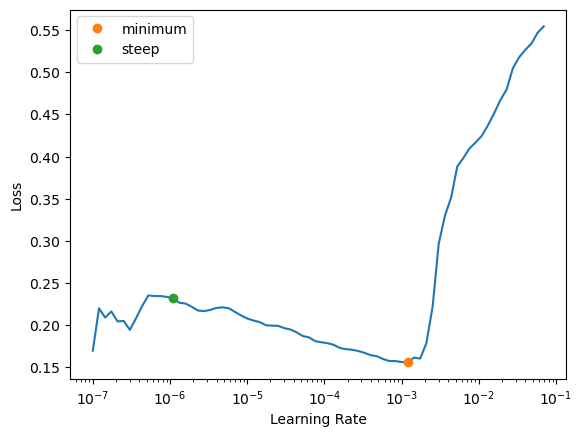

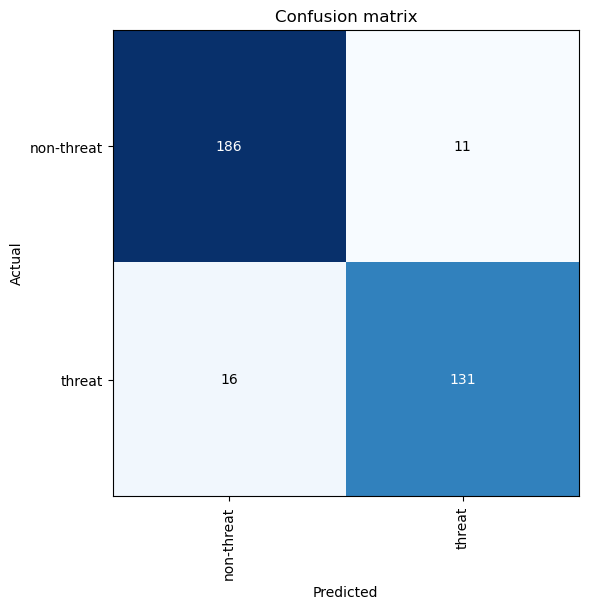

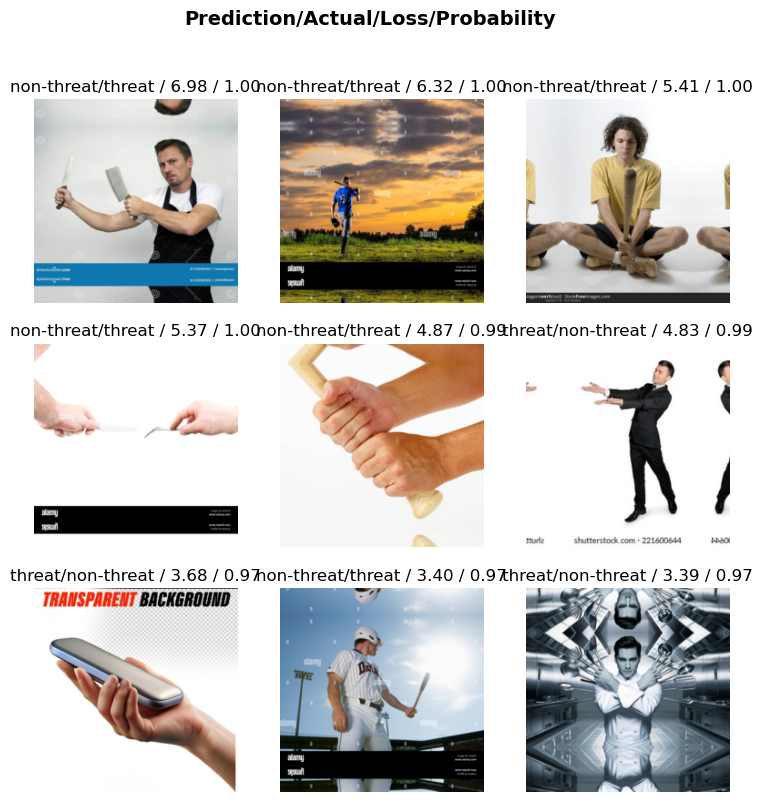

In [8]:
from fastai.vision.all import *
from PIL import ImageFile, Image
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None
import warnings
warnings.filterwarnings("ignore")


print("=== Script Started ===")

# ----------------------------
# Settings
# ----------------------------
print("Loading settings...")

DATA_PATH = Path('/scratch/hdhiran/data')     # <-- your data folder containing the 7 subfolders
MODEL_EXPORT_NAME = 'threat_detector_resnet34.pkl'
IMG_SIZE = 224
SEED = 42
torch.backends.cudnn.benchmark = True

set_seed(SEED, reproducible=True)
print(f"Using seed = {SEED}")

# ----------------------------
# Labeling function
# ----------------------------
print("Defining labeling function...")

THREAT_CLASSES = {'baseball_bat_in_hand', 'knife_in_hand', 'gun_in_hand'}

def is_threat(p:Path):
    return 'threat' if p.parent.name in THREAT_CLASSES else 'non-threat'

# ----------------------------
# DataBlock + Transforms
# ----------------------------
print("Setting up item transforms...")

item_tfms = [Resize(IMG_SIZE, method=ResizeMethod.Pad, pad_mode='reflection')]

print("Setting up batch transforms...")
batch_tfms = aug_transforms(
    do_flip=True,
    flip_vert=False,
    max_rotate=10.0,
    max_zoom=1.0,
    max_warp=0.05,
    max_lighting=0.2,
    pad_mode='reflection',
)

batch_tfms = batch_tfms + [Normalize.from_stats(*imagenet_stats)]

print("Creating DataBlock...")
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.20, seed=SEED),
    get_y=is_threat,
    item_tfms=item_tfms,
    batch_tfms=batch_tfms
)

# ----------------------------
# Dataloaders creation
# ----------------------------
print("=== Dataloaders: Starting creation ===")
NUM_WORKERS = 24
BS_TOTAL = 128
PIN_MEM = True

print(f"Using NUM_WORKERS={NUM_WORKERS}, batch_size={BS_TOTAL}, pin_memory={PIN_MEM}")
print("Scanning image files and constructing dataset...")

dls = dblock.dataloaders(DATA_PATH, bs=BS_TOTAL, num_workers=NUM_WORKERS, pin_memory=PIN_MEM)

print("=== Dataloaders: Finished creation ===")
print(f"Classes: {dls.vocab}")
print(f"Training batches: {len(dls.train)}, Validation batches: {len(dls.valid)}")

print("Showing a batch sample...")
dls.show_batch(max_n=9, figsize=(8,6))
print("Batch sample displayed.")

# ----------------------------
# Learner creation
# ----------------------------
print("=== Creating learner with ResNet34 ===")

learn = vision_learner(
    dls,
    resnet34,
    metrics=[accuracy, Precision(average='binary'), Recall(average='binary')],
    pretrained=True
).to_fp16()

print("Learner created. Moving to GPUs and wrapping parallel if needed...")

if torch.cuda.device_count() > 1:
    print(f"Detected {torch.cuda.device_count()} GPUs → Using DataParallel.")
    learn.model = torch.nn.DataParallel(learn.model)
else:
    print("Single GPU detected.")

print("Learner is ready.")

# ----------------------------
# Training: Phase 1 (Frozen)
# ----------------------------
print("\n==============================")
print("== Phase 1: Frozen Training ==")
print("==============================")

print("Starting fine_tune (3 epochs, frozen)...")
learn.fine_tune(3, base_lr=2e-3)
print("Phase 1 completed.")

# ----------------------------
# Training: Phase 2 (Unfreeze)
# ----------------------------
print("\n=======================================")
print("== Phase 2: Unfreeze and Fine-tuning ==")
print("=======================================")

learn.unfreeze()
print("Model unfrozen.")

print("Running lr_find... (this may take ~20–40 sec)")
lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
print(f"LR Finder Results → minimum: {lr_min}, steep: {lr_steep}")

chosen_lr = lr_steep if lr_steep is not None else 1e-3
print(f"Chosen LR range: slice({chosen_lr/10}, {chosen_lr})")

print("Starting fit_one_cycle (10 epochs)...")
learn.fit_one_cycle(10, lr_max=slice(chosen_lr/10, chosen_lr))
print("Phase 2 completed.")

# ----------------------------
# Evaluation
# ----------------------------
print("\n=======================")
print("== Model Evaluation ==")
print("=======================")

print("Validating model...")
val_loss, val_acc = learn.validate()[:2]
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

print("Plotting confusion matrix...")
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(6,6), dpi=100)

print("Showing top losses...")
interp.print_classification_report()
interp.plot_top_losses(9, figsize=(9,9))

# ----------------------------
# Export
# ----------------------------
print("============================")
print("== Saving / Exporting Model ==")
print("============================")

# Unwrap DataParallel for export
if isinstance(learn.model, torch.nn.DataParallel):
    print("Unwrapping nn.DataParallel...")
    learn.model = learn.model.module

learn.export(MODEL_EXPORT_NAME)
print(f"Model exported to: {MODEL_EXPORT_NAME}")

learn.save('threat_resnet34_full')
print("Model weights (learn.save) saved.")

